In [17]:
!pip install -q earth2studio[stormcast]

In [18]:
import numpy as np
import xarray as xr
import earth2studio.run as run
import matplotlib.pyplot as plt

from datetime import datetime
from scipy.interpolate import RegularGridInterpolator
from earth2studio.models.px import StormCast
from earth2studio.data import HRRR, GFS_FX
from earth2studio.io import ZarrBackend

class MyLocalData:
    """
    Wraps a local numpy array into the xarray interface expected by earth2studio.

    Args:
        data:      numpy array of shape (nt, ny, nx, nc)
                   nt: number of timesteps, ny/nx: spatial grid, nc: number of variables
        variables: list of variable name strings matching StormCast's expected inputs
        lats:      1D array of length ny — y-coordinate values (hrrr_y)
        lons:      1D array of length nx — x-coordinate values (hrrr_x)
        times:     list of datetimes of length nt, one per time slice in data
    """

    def __init__(
        self,
        data: np.ndarray,
        variables: list[str],
        lats: np.ndarray,
        lons: np.ndarray,
        times: list[datetime],
    ):
        nt, ny, nx, nc = data.shape
        assert len(times) == nt, f"Expected {nt} timestamps, got {len(times)}"
        assert len(variables) == nc, f"Expected {nc} variable names, got {len(variables)}"
        assert len(lats) == ny and len(lons) == nx, "lats/lons size mismatch with data grid"

        self.data = data
        self.variables = variables
        self.lats = lats
        self.lons = lons
        self.times = times

    def __call__(self, time: list[datetime], variable: list[str] | str) -> xr.DataArray:
        """
        Called by earth2studio at each forecast step to fetch input data.

        Args:
            time:     list of datetimes requested (earth2studio always passes a list)
            variable: variable name(s) to return

        Returns:
            xr.DataArray with dims (time, variable, hrrr_y, hrrr_x)
        """
        if isinstance(variable, str):
            variable = [variable]

        # Find the index in our stored times closest to the requested time.
        # For a single-IC case this will always be index 0.
        t_idx = self.times.index(time[0]) if time[0] in self.times else 0

        da = xr.DataArray(
            self.data[t_idx][np.newaxis, ...],   # (1, ny, nx, nc)
            dims=["time", "hrrr_y", "hrrr_x", "variable"],
            coords={
                "time": [time[0]],
                "hrrr_y": self.lats,
                "hrrr_x": self.lons,
                "variable": self.variables,
            },
        )

        return da.sel(variable=variable).transpose("time", "variable", "hrrr_y", "hrrr_x")

In [19]:
# --- Setup ---

VARIABLES = [
    'v20hl', 'q1hl',  'u3hl',  't2m',   'u20hl', 'v25hl', 'v5hl',  'Z2hl',
    'v9hl',  'p6hl',  'Z3hl',  'u10m',  't1hl',  't9hl',  'p4hl',  'Z5hl',
    'u10hl', 'v10m',  'q7hl',  'Z20hl', 'u6hl',  'Z6hl',  'q20hl', 'v10hl',
    't4hl',  'Z4hl',  'q30hl', 'p15hl', 'p2hl',  'q15hl', 'p7hl',  'Z25hl',
    'p3hl',  'p20hl', 't7hl',  't30hl', 'u1hl',  't2hl',  't11hl', 'p1hl',
    'q4hl',  't15hl', 'v2hl',  'p11hl', 'p8hl',  'v11hl', 'Z10hl', 'Z30hl',
    't3hl',  'v1hl',  'Z9hl',  'q11hl', 'Z11hl', 't20hl', 'p5hl',  'q8hl',
    'q5hl',  'u4hl',  't13hl', 'p9hl',  'q25hl', 'Z13hl', 'p13hl', 'v30hl',
    'q9hl',  'v4hl',  'mslp',  'q3hl',  'q13hl', 'Z15hl', 't10hl', 'refc',
    'Z7hl',  'Z1hl',  'p10hl', 'u8hl',  'u25hl', 'v8hl',  'u15hl', 'v15hl',
    'u2hl',  'q2hl',  'u11hl', 't5hl',  'v3hl',  'Z8hl',  't8hl',  't25hl',
    'u7hl',  'u5hl',  'u30hl', 'u9hl',  'v6hl',  'q10hl', 'v13hl', 'u13hl',
    'q6hl',  't6hl',  'v7hl',
]

NY, NX = 512, 640
starting_time = datetime(year=2024, month=6, day=1, hour=0)

# Placeholder: random data. Shape is (nt, ny, nx, nc).
# Replace this with your ERA5-derived array once the conversion is ready.
data = np.random.rand(1, NY, NX, len(VARIABLES))

my_data = MyLocalData(
    data=data,
    variables=VARIABLES,
    lats=np.arange(NY),
    lons=np.arange(NX),
    times=[starting_time],
)

# Quick sanity check before running inference
sample = my_data([starting_time], VARIABLES)
print("Sample dims: ", sample.dims)
print("Sample shape:", sample.shape)

Sample dims:  ('time', 'variable', 'hrrr_y', 'hrrr_x')
Sample shape: (1, 99, 512, 640)


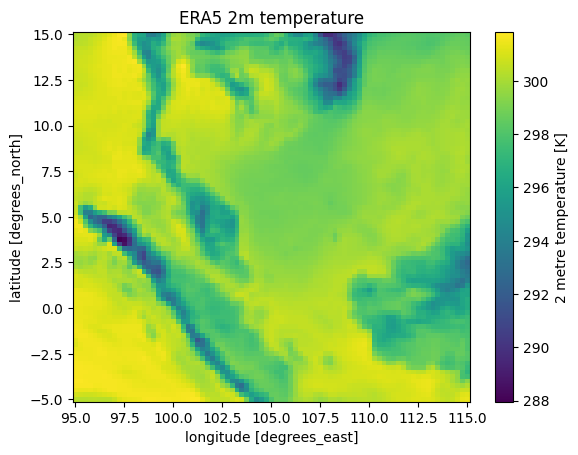

In [20]:
# basic check of input data

era5_path = "/content/era5_t2m.nc"
ds = xr.open_dataset(era5_path)

ds["t2m"].isel(valid_time=0).plot()
plt.title("ERA5 2m temperature")
plt.show()

In [21]:
ds = xr.open_dataset("era5_t2m.nc")

# Extract raw numpy arrays immediately
t2m = ds["t2m"].isel(valid_time=0).values      # (29, 33)
src_lats = ds.latitude.values                   # descending: [5.0, 4.75, ..., -2.0]
src_lons = ds.longitude.values                  # ascending:  [100.0, ..., 108.0]

print("t2m shape:", t2m.shape)
print("lats:", src_lats)
print("lons:", src_lons)

# Flip lats to ascending order (RegularGridInterpolator requires this)
src_lats_asc = src_lats[::-1]
t2m_asc = t2m[::-1, :]

interp_fn = RegularGridInterpolator(
    (src_lats_asc, src_lons),
    t2m_asc,
    method="linear",
    bounds_error=False,
    fill_value=np.nan,
)

# Target grid: NY×NX over the same lat/lon extent
target_lats = np.linspace(src_lats_asc.min(), src_lats_asc.max(), NY)
target_lons = np.linspace(src_lons.min(), src_lons.max(), NX)

grid_lons, grid_lats = np.meshgrid(target_lons, target_lats)
points = np.stack([grid_lats.ravel(), grid_lons.ravel()], axis=-1)

t2m_regridded = interp_fn(points).reshape(NY, NX)

print("Regridded shape:", t2m_regridded.shape)
print("Min:", t2m_regridded.min(), "Max:", t2m_regridded.max())

t2m shape: (81, 81)
lats: [15.   14.75 14.5  14.25 14.   13.75 13.5  13.25 13.   12.75 12.5  12.25
 12.   11.75 11.5  11.25 11.   10.75 10.5  10.25 10.    9.75  9.5   9.25
  9.    8.75  8.5   8.25  8.    7.75  7.5   7.25  7.    6.75  6.5   6.25
  6.    5.75  5.5   5.25  5.    4.75  4.5   4.25  4.    3.75  3.5   3.25
  3.    2.75  2.5   2.25  2.    1.75  1.5   1.25  1.    0.75  0.5   0.25
  0.   -0.25 -0.5  -0.75 -1.   -1.25 -1.5  -1.75 -2.   -2.25 -2.5  -2.75
 -3.   -3.25 -3.5  -3.75 -4.   -4.25 -4.5  -4.75 -5.  ]
lons: [ 95.    95.25  95.5   95.75  96.    96.25  96.5   96.75  97.    97.25
  97.5   97.75  98.    98.25  98.5   98.75  99.    99.25  99.5   99.75
 100.   100.25 100.5  100.75 101.   101.25 101.5  101.75 102.   102.25
 102.5  102.75 103.   103.25 103.5  103.75 104.   104.25 104.5  104.75
 105.   105.25 105.5  105.75 106.   106.25 106.5  106.75 107.   107.25
 107.5  107.75 108.   108.25 108.5  108.75 109.   109.25 109.5  109.75
 110.   110.25 110.5  110.75 111.   111.25 111.5

In [22]:
# Find which index in VARIABLES corresponds to 't2m'
t2m_idx = VARIABLES.index('t2m')
print(f"t2m is at index {t2m_idx}")  # should be 3

# Start with random data for all 99 variables
data = np.random.rand(1, NY, NX, len(VARIABLES)).astype(np.float32)

# Slot in the real regridded t2m at the correct channel index
data[0, :, :, t2m_idx] = t2m_regridded

print("data shape:", data.shape)
print(f"t2m channel min/max: {data[0,:,:,t2m_idx].min():.2f}, {data[0,:,:,t2m_idx].max():.2f}")

t2m is at index 3
data shape: (1, 512, 640, 99)
t2m channel min/max: 288.05, 301.83


In [23]:
my_data = MyLocalData(
    data=data,
    variables=VARIABLES,
    lats=target_lats,   # the actual lat values from regridding
    lons=target_lons,   # the actual lon values from regridding
    times=[starting_time],
)

sample = my_data([starting_time], VARIABLES)
print("Sample dims:", sample.dims)
print("Sample shape:", sample.shape)

Sample dims: ('time', 'variable', 'hrrr_y', 'hrrr_x')
Sample shape: (1, 99, 512, 640)


In [24]:
package = StormCast.load_default_package()
model = StormCast.load_model(package, conditioning_data_source=GFS_FX())

io = ZarrBackend("stormcast_output_era5.zarr", backend_kwargs={"overwrite": True})
io = run.deterministic(time=[starting_time], nsteps=2, prognostic=model, data=my_data, io=io)

2026-05-27 02:43:10.540 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-05-27 02:43:10.540 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda
2026-05-27 02:43:11.314 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from MyLocalData
2026-05-27 02:43:11.614 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-27 02:43:13.851 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f000 214550828-614032
2026-05-27 02:43:13.890 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f000 419046881-879915
2026-05-27 02:43:13.928 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f000 341235877-862138
2026-05-27 02:43:13.964 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f000 404533150-967534
2026-05-27 02:43:14.000 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f000 262728604-753478
2026-05-27 02:43:14.042 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 



Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-27 02:43:14.081 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f000 430855049-1235767
2026-05-27 02:43:14.122 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f000 209044365-774104
2026-05-27 02:43:14.162 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f000 268990514-579343
2026-05-27 02:43:14.197 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f000 410796278-846536
2026-05-27 02:43:14.235 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f000 400374183-1259707


...

2026-05-27 02:44:26.471 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 264499337-753288
2026-05-27 02:44:26.510 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 421538202-879009
2026-05-27 02:44:26.553 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 350056683-972733
2026-05-27 02:44:26.593 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 209783513-771628
2026-05-27 02:44:26.633 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 270761448-579586
2026-05-27 02:44:26.670 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 



Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data: 100%|██████████| 26/26 [00:01<00:00, 24.81it/s]


2026-05-27 02:44:26.713 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 428269022-958273
2026-05-27 02:44:26.747 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 215901179-620268
2026-05-27 02:44:26.783 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 345364642-1273438



Running inference: 100%|██████████| 3/3 [02:25<00:00, 48.59s/it]

2026-05-27 02:45:37.384 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete


In [25]:
ds_out = xr.open_zarr("stormcast_output_era5.zarr")
print(ds_out)

ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7b4fd1f1f590>


<xarray.Dataset> Size: 389MB
Dimensions:    (time: 1, lead_time: 3, hrrr_y: 512, hrrr_x: 640)
Coordinates:
  * time       (time) datetime64[ns] 8B 2024-06-01
  * lead_time  (lead_time) timedelta64[h] 24B 00:00:00 01:00:00 02:00:00
  * hrrr_y     (hrrr_y) float64 4kB -7.683e+05 -7.653e+05 ... 7.647e+05
  * hrrr_x     (hrrr_x) float64 5kB -9.605e+05 -9.575e+05 ... 9.565e+05
Data variables: (12/99)
    Z8hl       (time, lead_time, hrrr_y, hrrr_x) float32 4MB dask.array<chunksize=(1, 1, 512, 640), meta=np.ndarray>
    t4hl       (time, lead_time, hrrr_y, hrrr_x) float32 4MB dask.array<chunksize=(1, 1, 512, 640), meta=np.ndarray>
    v15hl      (time, lead_time, hrrr_y, hrrr_x) float32 4MB dask.array<chunksize=(1, 1, 512, 640), meta=np.ndarray>
    q1hl       (time, lead_time, hrrr_y, hrrr_x) float32 4MB dask.array<chunksize=(1, 1, 512, 640), meta=np.ndarray>
    u10m       (time, lead_time, hrrr_y, hrrr_x) float32 4MB dask.array<chunksize=(1, 1, 512, 640), meta=np.ndarray>
    t5hl       (

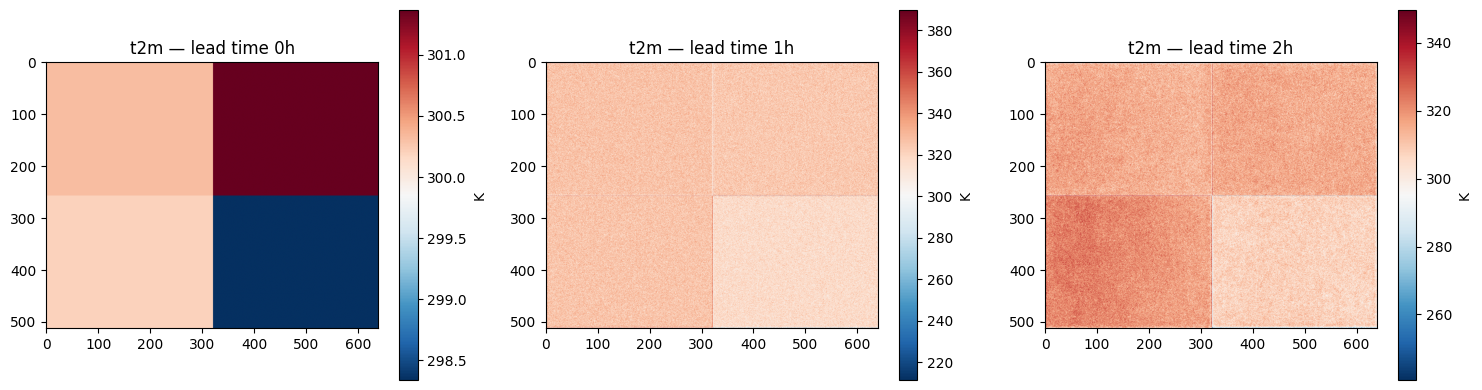

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for step in range(3):
    field = ds_out["t2m"].isel(time=0, lead_time=step).values
    im = axes[step].imshow(field, origin="upper", cmap="RdBu_r")
    axes[step].set_title(f"t2m — lead time {step}h")
    plt.colorbar(im, ax=axes[step], label="K")

plt.tight_layout()
plt.show()